Title: capacity_data_offshore.ipynb

Purpose: Transform the xml capacity data into some gridded format (The gross power output as well as the hub height)

Author: Onno Nennecke on 10.02.2025 Modified: 17.02.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

In [ ]:
import pandas as pd
import geopandas as gpd
import xml.etree.ElementTree as ET
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:
# Load the XML file
tree = ET.parse('/climca/people/onennecke/Wind_Solar_MaStR/EinheitenWind.xml')
root = tree.getroot()


Felder relevant:
columns_to_keep = ['EinheitMastrNummer', 'Postleitzahl', 'Bruttoleistung', 'Nettonennleistung',
  'Lage', 'NameWindpark', 'Nabenhoehe', 'Rotordurchmesser', 
  'Seelage', 'ClusterNordsee', 'Wassertiefe', 'Kuestenentfernung', 'ClusterOstsee', 'Laengengrad',
  'Breitengrad']

Liste Felder nicht relevant:
columns_to_loose = ['DatumLetzteAktualisierung', 'LokationMaStRNummer',
       'NetzbetreiberpruefungStatus', 'AnlagenbetreiberMastrNummer', 'Land', 
       'Bundesland', 'Landkreis', 'Gemeinde', 'Gemeindeschluessel', 'Ort',
       'Registrierungsdatum', 'Inbetriebnahmedatum', 'EinheitSystemstatus',
       'EinheitBetriebsstatus', 'NichtVorhandenInMigriertenEinheiten',
       'NameStromerzeugungseinheit', 'Weic_nv', 'Kraftwerksnummer_nv',
       'Energietraeger', 'FernsteuerbarkeitNb', 'Einspeisungsart', 'EegMaStRNummer',
       'DatumBeginnVoruebergehendeStilllegung', 'NetzbetreiberpruefungDatum',
       'Adresszusatz', 'FernsteuerbarkeitDv', 'DatumDesBetreiberwechsels',
       'DatumRegistrierungDesBetreiberwechsels', 'Gemarkung', 'FlurFlurstuecknummern',
       'AnschlussAnHoechstOderHochSpannung', 
       'DatumEndgueltigeStilllegung', 'Strasse', 'StrasseNichtGefunden', 'Hausnummer_nv',
       'HausnummerNichtGefunden',
       'GenMastrNummer', 'Einsatzverantwortlicher', 'WeicDisplayName',
       'DatumWiederaufnahmeBetrieb', 'GeplantesInbetriebnahmedatum',
       'Buergerenergie', 'Kraftwerksnummer','Hersteller', 'Technologie', 'Typenbezeichnung',
       'Rotorblattenteisungssystem', 'AuflageAbschaltungLeistungsbegrenzung',
       'AuflagenAbschaltungSchallimmissionsschutzNachts',
       'AuflagenAbschaltungSchallimmissionsschutzTagsueber',
       'AuflagenAbschaltungSchattenwurf', 'AuflagenAbschaltungTierschutz',
       'AuflagenAbschaltungEiswurf', 'AuflagenAbschaltungSonstige',
       'Nachtkennzeichnung','Hausnummer']

In [3]:
rows = []

for einheit in root.findall('EinheitWind'):
        einheit_data = {
            'EinheitMastrNummer': einheit.find('EinheitMastrNummer').text,
            'Bruttoleistung': float(einheit.find('Bruttoleistung').text),
            'Nettonennleistung': float(einheit.find('Nettonennleistung').text),
            'Lage': int(einheit.find('Lage').text) if einheit.find('Lage') is not None else np.nan,
            'NameWindpark': einheit.find('NameWindpark').text if einheit.find('NameWindpark') is not None else np.nan,
            'Nabenhoehe': float(einheit.find('Nabenhoehe').text) if einheit.find('Nabenhoehe') is not None else np.nan,
            'Rotordurchmesser': float(einheit.find('Rotordurchmesser').text) if einheit.find('Rotordurchmesser') is not None else np.nan,
            'Seelage': int(einheit.find('Seelage').text) if einheit.find('Seelage') is not None else np.nan,
            # 'ClusterNordsee': int(einheit.find('ClusterNordsee').text) if einheit.find('ClusterNordsee') is not None else np.nan,
            # 'ClusterOstsee': int(einheit.find('ClusterOstsee').text) if einheit.find('ClusterOstsee') is not None else np.nan,
            'Wassertiefe': float(einheit.find('Wassertiefe').text) if einheit.find('Wassertiefe') is not None else np.nan,
            'Kuestenentfernung': float(einheit.find('Kuestenentfernung').text) if einheit.find('Kuestenentfernung') is not None else np.nan,
            'Laengengrad': float(einheit.find('Laengengrad').text) if einheit.find('Laengengrad') is not None else np.nan,
            'Breitengrad': float(einheit.find('Breitengrad').text) if einheit.find('Breitengrad') is not None else np.nan,
            'EinheitBetriebsstatus': int(einheit.find('EinheitBetriebsstatus').text)
        }
        rows.append(einheit_data)


# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(rows)

# Display the resulting DataFrame
print(df)

      EinheitMastrNummer  Bruttoleistung  Nettonennleistung   Lage  \
0        SEE940146675093          3000.0             3000.0  888.0   
1        SEE973767078653          3000.0             3000.0  888.0   
2        SEE914108319653          3000.0             3000.0  888.0   
3        SEE982417853618          3000.0             3000.0  888.0   
4        SEE913741454097          2400.0             2400.0  888.0   
...                  ...             ...                ...    ...   
38070    SEE938428285726          3500.0             3500.0  888.0   
38071    SEE987122644452          3500.0             3500.0  888.0   
38072    SEE924447498896          3500.0             3500.0  888.0   
38073    SEE938294352034          4200.0             4200.0  888.0   
38074    SEE987180399516          7200.0             7200.0  888.0   

                  NameWindpark  Nabenhoehe  Rotordurchmesser  Seelage  \
0          Windpark Kreuzstein      149.08            115.71      NaN   
1            

In [4]:
# Drop closed units
print(len(df[df['EinheitBetriebsstatus'] != 35]))
df_1 = df[df['EinheitBetriebsstatus'] == 35].copy() # 35 == In Betrieb

# Drop on-shore units
df_2 = df_1[df_1['Lage'] == 889].copy()

# Drop columns EinheitBetriebsstatus and Lage as they are no longer needed
df_2.drop(columns=['EinheitBetriebsstatus', 'Lage'], inplace=True)

6689


In [5]:
# Some data inspection

df_2['Kuestenentfernung'].isna().sum()

df_2['Wassertiefe'].isna().sum()

df_2[df_2['Kuestenentfernung'].isna()]

# Are all in one windpark

,EinheitMastrNummer,Bruttoleistung,Nettonennleistung,NameWindpark,Nabenhoehe,Rotordurchmesser,Seelage,Wassertiefe,Kuestenentfernung,Laengengrad,Breitengrad
33296,SEE976484472155,9525.0,9525.0,Arcadis Ost I,NaN,174.0,639.0,NaN,NaN,13.633671,54.835705
33299,SEE919634644811,9525.0,9525.0,Arcadis Ost I,NaN,174.0,639.0,NaN,NaN,13.692653,54.816901
33300,SEE972365776404,9525.0,9525.0,Arcadis Ost I,NaN,174.0,639.0,NaN,NaN,13.709225,54.809033
33301,SEE943730653286,9525.0,9525.0,Arcadis Ost I,NaN,174.0,639.0,NaN,NaN,13.593805,54.832862
33305,SEE997044217061,9525.0,9525.0,Arcadis Ost I,NaN,174.0,639.0,NaN,NaN,13.612993,54.827864
33306,SEE977833094349,9525.0,9525.0,Arcadis Ost I,NaN,174.0,639.0,NaN,NaN,13.633509,54.820231
33307,SEE915928154257,9525.0,9525.0,Arcadis Ost I,NaN,174.0,639.0,NaN,NaN,13.651127,54.817461
33308,SEE934697756301,9525.0,9525.0,Arcadis Ost I,NaN,174.0,639.0,NaN,NaN,13.679713,54.809937
33309,SEE934361982159,9525.0,9525.0,Arcadis Ost I,NaN,174.0,639.0,NaN,NaN,13.573086,54.829979
33310,SEE905567222776,9525.0,9525.0,Arcadis Ost I,NaN,174.0,639.0,NaN,NaN,13.611575,54.819680


In [6]:
# Transform to shapefile
gdf = gpd.GeoDataFrame(df_2, geometry=gpd.points_from_xy(df_2['Laengengrad'], df_2['Breitengrad']))
gdf.crs = 'EPSG:4326'

In [ ]:
gdf.to_file('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/offshore_windparks.shp')

/tmp/ipykernel_253148/4050930805.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/offshore_windparks.shp')
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'EinheitMastrNummer' to 'EinheitMas'
  ogr_write(
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Bruttoleistung' to 'Bruttoleis'
  ogr_write(
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Nettonennleistung' to 'Nettonennl'
  ogr_write(
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'NameWindpark' to 'NameWindpa'
  ogr_write(
/home/onennecke/.conda/envs/on_

In [ ]:
# Load climate data as a grid reference
nc = xr.open_dataset('/climca/data/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/day/sfcWind/gn/v20190308/sfcWind_day_CESM2_historical_r1i1p1f1_gn_18500101-18591231.nc')
nc = nc.sel(dict(lat=slice(45,60), lon=slice(5,15))) # At the moment roughly germany
# Koordinaten des Rasters extrahieren
lats = nc['lat'].values  # Latitude
lons = nc['lon'].values  # Longitude

# Optional: Werte für das leere Grid initialisieren (z. B. mit NaN oder 0)
wind_off_cap = np.full((len(lats), len(lons)), np.nan)

# Neues xarray.DataArray basierend auf den Dimensionen erstellen
grid = xr.DataArray(
    data=wind_off_cap,
    coords={"lat": lats, "lon": lons},
    dims=["lat", "lon"],
    name="wind_off_cap"
)
grid
grid['crs'] = 4326
grid['lat'].attrs['standard_name'] = 'latitude'
grid['lon'].attrs['standard_name'] = 'longitude'

/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [8]:
gdf

,EinheitMastrNummer,Bruttoleistung,Nettonennleistung,NameWindpark,Nabenhoehe,Rotordurchmesser,Seelage,Wassertiefe,Kuestenentfernung,Laengengrad,Breitengrad,geometry
223,SEE991181426935,6300.0,6300.0,OWP Veja Mate,103.28,154.0,640.0,39.8,63.923,5.828958,54.341550,POINT (5.82896 54.34155)
303,SEE948492783349,3780.0,3780.0,OWP DanTysk,88.00,120.0,640.0,29.8,50.570,7.174499,55.067578,POINT (7.1745 55.06758)
338,SEE996261343003,3780.0,3780.0,OWP DanTysk,88.00,120.0,640.0,28.7,50.650,7.175124,55.075620,POINT (7.17512 55.07562)
623,SEE990582178207,3780.0,3780.0,Baltic 2,78.25,120.0,639.0,42.6,30.740,13.083867,54.949617,POINT (13.08387 54.94962)
627,SEE969452881615,3780.0,3780.0,Baltic 2,78.25,120.0,639.0,42.0,31.230,13.092806,54.957388,POINT (13.09281 54.95739)
...,...,...,...,...,...,...,...,...,...,...,...,...
34289,SEE982413596991,11550.0,11550.0,Gode Wind 3,126.50,200.0,640.0,30.2,22.200,7.096548,54.030592,POINT (7.09655 54.03059)
34290,SEE905373051485,11550.0,11550.0,Gode Wind 3,126.50,200.0,640.0,29.9,22.000,7.085100,54.023670,POINT (7.0851 54.02367)
34291,SEE942700031529,11550.0,11550.0,Gode Wind 3,126.50,200.0,640.0,29.5,21.700,7.073857,54.016865,POINT (7.07386 54.01686)
34292,SEE980736061066,11550.0,11550.0,Gode Wind 3,126.50,200.0,640.0,29.0,21.500,7.063277,54.010465,POINT (7.06328 54.01046)


In [9]:
# Wandle Koordinaten in das Grid-Koordinatensystem
gdf["lat_idx"] = np.searchsorted(grid['lat'], gdf["Breitengrad"]) # Zeilenindex für Latitude
gdf["lon_idx"] = np.searchsorted(grid['lon'], gdf["Laengengrad"]) # Spaltenindex für Longitude

gdf

,EinheitMastrNummer,Bruttoleistung,Nettonennleistung,NameWindpark,Nabenhoehe,Rotordurchmesser,Seelage,Wassertiefe,Kuestenentfernung,Laengengrad,Breitengrad,geometry,lat_idx,lon_idx
223,SEE991181426935,6300.0,6300.0,OWP Veja Mate,103.28,154.0,640.0,39.8,63.923,5.828958,54.341550,POINT (5.82896 54.34155),10,1
303,SEE948492783349,3780.0,3780.0,OWP DanTysk,88.00,120.0,640.0,29.8,50.570,7.174499,55.067578,POINT (7.1745 55.06758),10,2
338,SEE996261343003,3780.0,3780.0,OWP DanTysk,88.00,120.0,640.0,28.7,50.650,7.175124,55.075620,POINT (7.17512 55.07562),10,2
623,SEE990582178207,3780.0,3780.0,Baltic 2,78.25,120.0,639.0,42.6,30.740,13.083867,54.949617,POINT (13.08387 54.94962),10,7
627,SEE969452881615,3780.0,3780.0,Baltic 2,78.25,120.0,639.0,42.0,31.230,13.092806,54.957388,POINT (13.09281 54.95739),10,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34289,SEE982413596991,11550.0,11550.0,Gode Wind 3,126.50,200.0,640.0,30.2,22.200,7.096548,54.030592,POINT (7.09655 54.03059),9,2
34290,SEE905373051485,11550.0,11550.0,Gode Wind 3,126.50,200.0,640.0,29.9,22.000,7.085100,54.023670,POINT (7.0851 54.02367),9,2
34291,SEE942700031529,11550.0,11550.0,Gode Wind 3,126.50,200.0,640.0,29.5,21.700,7.073857,54.016865,POINT (7.07386 54.01686),9,2
34292,SEE980736061066,11550.0,11550.0,Gode Wind 3,126.50,200.0,640.0,29.0,21.500,7.063277,54.010465,POINT (7.06328 54.01046),9,2


In [10]:
print(gdf['Laengengrad'].min())
print(gdf['Laengengrad'].max())

print(gdf['Breitengrad'].min())
print(gdf['Breitengrad'].max())

print(gdf['lat_idx'].min())
print(gdf['lat_idx'].max())

print(gdf['lon_idx'].min())
print(gdf['lon_idx'].max())

5.744082
14.179783
53.682009
55.294125
9
11
1
8


In [11]:
grid_sums = gdf.groupby(["lat_idx", "lon_idx"])["Bruttoleistung"].sum()
grid_sums

lat_idx  lon_idx
9        2          2979418.0
         3           110700.0
10       1          1203350.0
         2          1135840.0
         3          1530000.0
         7           607875.0
         8          1220350.0
11       2           427560.0
Name: Bruttoleistung, dtype: float64

In [22]:
# Schritt 4: Werte ins Grid schreiben
for (lat_idx, lon_idx), value in grid_sums.items():
    grid[lat_idx, lon_idx] = value

# Resultierendes Grid anzeigen
print(grid)

<xarray.DataArray 'wind_off_cap' (lat: 16, lon: 9)> Size: 1kB
array([[     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             n

In [27]:
gdf['Bruttoleistung'].sum()

np.float64(9215093.0)

In [23]:
# Save grid as raster file
grid.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_power.nc')

In [64]:
grid = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_power.nc')
grid

<xarray.Dataset> Size: 1kB
Dimensions:       (lat: 16, lon: 9)
Coordinates:
  * lat           (lat) float64 128B 45.71 46.65 47.59 ... 57.96 58.9 59.84
  * lon           (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
    crs           int64 8B ...
Data variables:
    wind_off_cap  (lat, lon) float64 1kB ...

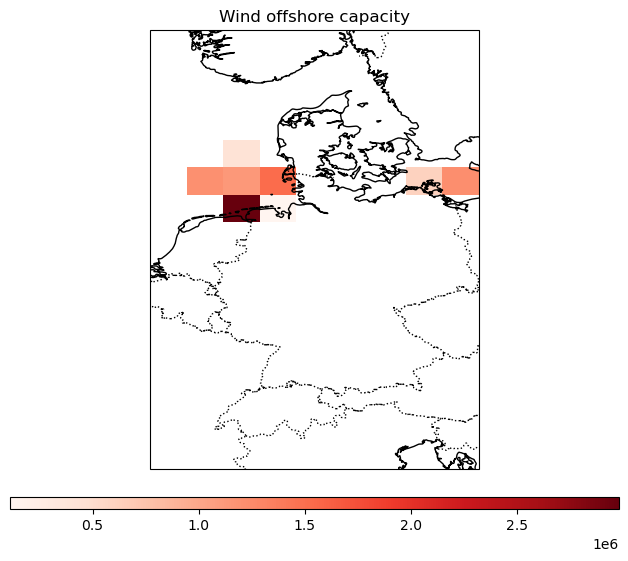

In [ ]:
lon_edges = grid.lon.values - (grid.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid.lat.values - (grid.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Plot the data

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# First subplot
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im = ax.pcolormesh(lon_edges, lat_edges, grid['wind_off_cap'], transform=ccrs.PlateCarree(), cmap='Reds')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax.set_title('Wind offshore capacity')

plt.tight_layout()
plt.show()

## Hub Height calculation

In [44]:
# Load climate data as a grid reference
nc = xr.open_dataset('/climca/data/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/day/sfcWind/gn/v20190308/sfcWind_day_CESM2_historical_r1i1p1f1_gn_18500101-18591231.nc')
nc = nc.sel(dict(lat=slice(45,60), lon=slice(5,15))) # At the moment roughly germany
# Koordinaten des Rasters extrahieren
lats = nc['lat'].values  # Latitude
lons = nc['lon'].values  # Longitude

# Optional: Werte für das leere Grid initialisieren (z. B. mit NaN oder 0)
wind_off_hub_height = np.full((len(lats), len(lons)), np.nan)

# Neues xarray.DataArray basierend auf den Dimensionen erstellen
grid_height = xr.DataArray(
    data=wind_off_hub_height,
    coords={"lat": lats, "lon": lons},
    dims=["lat", "lon"],
    name="wind_off_hub_height"
)
grid_height
grid_height['crs'] = 4326
grid_height['lat'].attrs['standard_name'] = 'latitude'
grid_height['lon'].attrs['standard_name'] = 'longitude'

/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


### Calculate weighted mean (Based upon the Bruttoleistung)

In [58]:
# Drop data without height values
gdf_2 = gdf.dropna(subset=['Nabenhoehe'])
# gdf_2

In [59]:
grid_mean_height_weighted = gdf_2.groupby(["lat_idx", "lon_idx"]).apply(lambda x: np.average(x["Nabenhoehe"], weights=x["Bruttoleistung"]))
grid_mean_height_weighted

/tmp/ipykernel_200201/3234131996.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grid_mean_height_weighted = gdf_2.groupby(["lat_idx", "lon_idx"]).apply(lambda x: np.average(x["Nabenhoehe"], weights=x["Bruttoleistung"]))


lat_idx  lon_idx
9        2          103.336626
         3           84.000000
10       1           99.626092
         2           97.994878
         3           95.152612
         7           76.700599
         8          102.601303
11       2           92.161886
dtype: float64

In [ ]:
# Werte ins Grid schreiben
for (lat_idx, lon_idx), value in grid_mean_height_weighted.items():
    grid_height[lat_idx, lon_idx] = value

# Resultierendes Grid anzeigen
# print(grid_height)

In [69]:
# Save grid as raster file
# grid_height.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')

# Open File
grid = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')
# grid

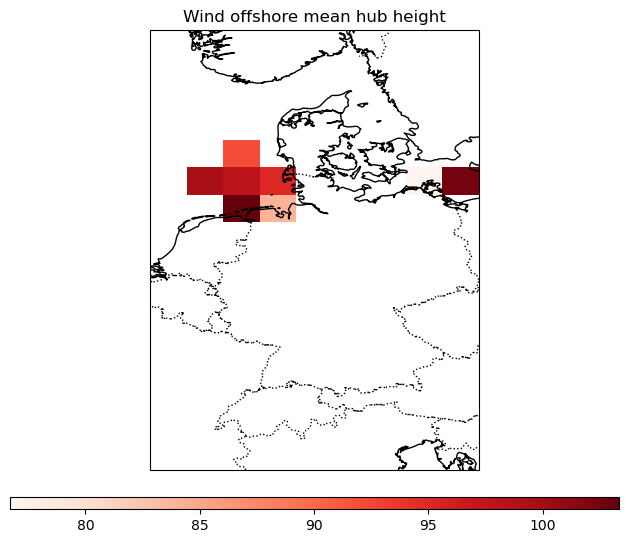

In [ ]:
lon_edges = grid.lon.values - (grid.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid.lat.values - (grid.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Plot the data

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# First subplot
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im = ax.pcolormesh(lon_edges, lat_edges, grid['wind_off_hub_height'], transform=ccrs.PlateCarree(), cmap='Reds')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax.set_title('Wind offshore mean hub height')

plt.tight_layout()
plt.show()

### With normal mean (probably obsolete)

In [ ]:
grid_mean_height = gdf.groupby(["lat_idx", "lon_idx"])["Nabenhoehe"].mean()
# grid_mean_height

In [ ]:
# Schritt 4: Werte ins Grid schreiben
for (lat_idx, lon_idx), value in grid_mean_height.items():
    grid_height[lat_idx, lon_idx] = value

# Resultierendes Grid anzeigen
# print(grid_height)

In [71]:
# Save grid as raster file
# grid_height.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height.nc')
grid = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height.nc')
grid

<xarray.Dataset> Size: 1kB
Dimensions:              (lat: 16, lon: 9)
Coordinates:
  * lat                  (lat) float64 128B 45.71 46.65 47.59 ... 58.9 59.84
  * lon                  (lon) float64 72B 5.0 6.25 7.5 8.75 ... 12.5 13.75 15.0
    crs                  int64 8B ...
Data variables:
    wind_off_hub_height  (lat, lon) float64 1kB ...

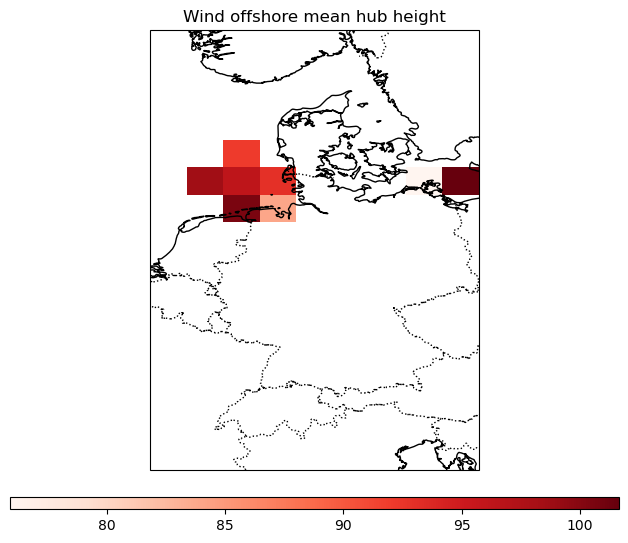

In [ ]:
lon_edges = grid.lon.values - (grid.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid.lat.values - (grid.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Plot the data

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# First subplot
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im = ax.pcolormesh(lon_edges, lat_edges, grid['wind_off_hub_height'], transform=ccrs.PlateCarree(), cmap='Reds')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax.set_title('Wind offshore mean hub height')

plt.tight_layout()
plt.show()